# Kuhn Poker de 3 jugadores

Esta notebook usa `games/kuhn3.py`, la implementación de Kuhn Poker de 3 jugadores provista por los profesores. El juego usa 4 cartas (`J`, `Q`, `K`, `A`) y 3 agentes.

Las acciones son binarias: `p` y `b`. La semántica exacta de terminales y rewards está definida en `KuhnPoker3._terminalset` y `KuhnPoker3._compute_rewards()`.

In [1]:
from pathlib import Path
import sys
import importlib.util
from time import perf_counter

import numpy as np
import matplotlib.pyplot as plt

CFR_DIR = Path.cwd() if Path.cwd().name == 'cfr' else Path.cwd() / 'cfr'
PROJECT_ROOT = CFR_DIR.parent
for path in [str(PROJECT_ROOT), str(CFR_DIR)]:
    if path not in sys.path:
        sys.path.insert(0, path)

from games.kuhn3 import KuhnPoker3
from agents.counterfactualregret import CounterFactualRegret


def load_class(module_path, class_name):
    spec = importlib.util.spec_from_file_location(class_name, module_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return getattr(module, class_name)


InformationSetMCTS = load_class(PROJECT_ROOT / 'agents' / 'ismcts.py', 'InformationSetMCTS')
RandomAgent = load_class(PROJECT_ROOT / 'agents' / 'agent_random.py', 'RandomAgent')

In [2]:
game = KuhnPoker3(play_order=[0, 1, 2], render_mode='')
game.reset()
print('Mano inicial:', game.hand())

while not game.game_over():
    agent = game.agent_selection
    action = np.random.choice(game.available_actions())
    print(f'{agent} juega {action} ({game.action_move(action)})')
    game.step(action)

print('Historial:', game._hist)
print('Rewards:', game.rewards)
print('Suma de rewards:', sum(game.rewards.values()))

Mano inicial: {'agent_0': 'J', 'agent_1': 'K', 'agent_2': 'A'}
agent_0 juega 0 (p)
agent_1 juega 0 (p)
agent_2 juega 0 (p)
Historial: ppp
Rewards: {'agent_0': np.int64(-1), 'agent_1': np.int64(-1), 'agent_2': np.int64(2)}
Suma de rewards: 0


## Comparación de agentes

Comparamos `CFR`, `ISMCTS` y `Random` en configuraciones de 3 jugadores. `CFR` aprende una política por infosets; `ISMCTS` hace búsqueda online con determinizaciones compatibles con la información privada de cada agente; `Random` sirve como baseline.

**Sobre el equilibrio de Nash:**
- Kuhn Poker de 3 jugadores SÍ tiene equilibrio de Nash, aunque es más complejo que en 2 jugadores
- No existe una fórmula analítica simple como -1/18 en el caso de 2 jugadores
- CFR puede aproximar este equilibrio con suficientes iteraciones de entrenamiento
- En equilibrio, los rewards esperados tienden a ser cercanos a 0 para todos los jugadores (ver sección siguiente)

Por eso la gráfica de esta sección se interpreta como comparación empírica de performance entre configuraciones, no como verificación contra un valor teórico conocido.

In [3]:
def bind_agents_to_game(agents, game):
    for agent in game.agents:
        agents[agent].game = game


def play_game(game, agents):
    bind_agents_to_game(agents, game)
    game.reset()
    while not game.done():
        action = agents[game.agent_selection].action()
        game.step(action)
    return game.rewards.copy()


def build_agent(
    kind,
    game,
    agent,
    cfr_niter=1_000,
    ismcts_simulations=100,
    ismcts_rollouts=3,
):
    if kind == 'cfr':
        player = CounterFactualRegret(game=game, agent=agent)
        player.train(cfr_niter)
        return player
    if kind == 'ismcts':
        return InformationSetMCTS(
            game=game,
            agent=agent,
            simulations=ismcts_simulations,
            rollouts=ismcts_rollouts,
        )
    if kind == 'random':
        return RandomAgent(game=game, agent=agent)
    raise ValueError(f'Unknown agent kind: {kind}')


def evaluate_match(
    kinds,
    n_games=1_000,
    play_order=[0, 1, 2],
    cfr_niter=1_000,
    ismcts_simulations=100,
    ismcts_rollouts=3,
    seed=None,
):
    train_game = KuhnPoker3(play_order=play_order, seed=seed, render_mode='')
    start = perf_counter()
    agents = {
        agent: build_agent(
            kind=kinds[agent],
            game=train_game,
            agent=agent,
            cfr_niter=cfr_niter,
            ismcts_simulations=ismcts_simulations,
            ismcts_rollouts=ismcts_rollouts,
        )
        for agent in train_game.agents
    }
    setup_time = perf_counter() - start

    eval_game = KuhnPoker3(play_order=play_order, seed=seed, render_mode='')
    cum_rewards = {agent: 0.0 for agent in eval_game.agents}
    wins = {agent: 0 for agent in eval_game.agents}

    start = perf_counter()
    for _ in range(n_games):
        rewards = play_game(eval_game, agents)
        for agent, reward in rewards.items():
            cum_rewards[agent] += reward
        winner = max(rewards, key=rewards.get)
        wins[winner] += 1
    eval_time = perf_counter() - start

    return {
        'kinds': kinds.copy(),
        'avg_rewards': {agent: cum_rewards[agent] / n_games for agent in eval_game.agents},
        'wins': wins,
        'setup_time': setup_time,
        'eval_time': eval_time,
    }

In [4]:
configs = [
    ('CFR vs CFR vs CFR', {'agent_0': 'cfr', 'agent_1': 'cfr', 'agent_2': 'cfr'}),
    ('ISMCTS vs ISMCTS vs ISMCTS', {'agent_0': 'ismcts', 'agent_1': 'ismcts', 'agent_2': 'ismcts'}),
    ('CFR vs ISMCTS vs ISMCTS', {'agent_0': 'cfr', 'agent_1': 'ismcts', 'agent_2': 'ismcts'}),
    ('ISMCTS vs CFR vs CFR', {'agent_0': 'ismcts', 'agent_1': 'cfr', 'agent_2': 'cfr'}),
    ('CFR vs CFR vs Random', {'agent_0': 'cfr', 'agent_1': 'cfr', 'agent_2': 'random'}),
    ('ISMCTS vs ISMCTS vs Random', {'agent_0': 'ismcts', 'agent_1': 'ismcts', 'agent_2': 'random'}),
    ('Random vs Random vs Random', {'agent_0': 'random', 'agent_1': 'random', 'agent_2': 'random'}),
]

results = []
for label, kinds in configs:
    result = evaluate_match(
        kinds=kinds,
        n_games=1_000,
        play_order=[0, 1, 2],
        cfr_niter=1_000,
        ismcts_simulations=100,
        ismcts_rollouts=3,
        seed=None,
    )
    result['label'] = label
    results.append(result)
    print(
        f"{label:<28} | "
        f"avg={result['avg_rewards']} | "
        f"wins={result['wins']} | "
        f"setup={result['setup_time']:.2f}s | eval={result['eval_time']:.2f}s"
    )

CFR vs CFR vs CFR            | avg={'agent_0': np.float64(-0.012), 'agent_1': np.float64(-0.023), 'agent_2': np.float64(0.035)} | wins={'agent_0': 337, 'agent_1': 342, 'agent_2': 321} | setup=32.57s | eval=0.12s
ISMCTS vs ISMCTS vs ISMCTS   | avg={'agent_0': np.float64(-0.08), 'agent_1': np.float64(0.004), 'agent_2': np.float64(0.076)} | wins={'agent_0': 323, 'agent_1': 335, 'agent_2': 342} | setup=0.00s | eval=472.86s
CFR vs ISMCTS vs ISMCTS      | avg={'agent_0': np.float64(-0.013), 'agent_1': np.float64(-0.091), 'agent_2': np.float64(0.104)} | wins={'agent_0': 329, 'agent_1': 325, 'agent_2': 346} | setup=22.35s | eval=394.40s
ISMCTS vs CFR vs CFR         | avg={'agent_0': np.float64(-0.083), 'agent_1': np.float64(0.023), 'agent_2': np.float64(0.06)} | wins={'agent_0': 357, 'agent_1': 309, 'agent_2': 334} | setup=44.52s | eval=265.16s
CFR vs CFR vs Random         | avg={'agent_0': np.float64(0.086), 'agent_1': np.float64(0.119), 'agent_2': np.float64(-0.205)} | wins={'agent_0': 321, 

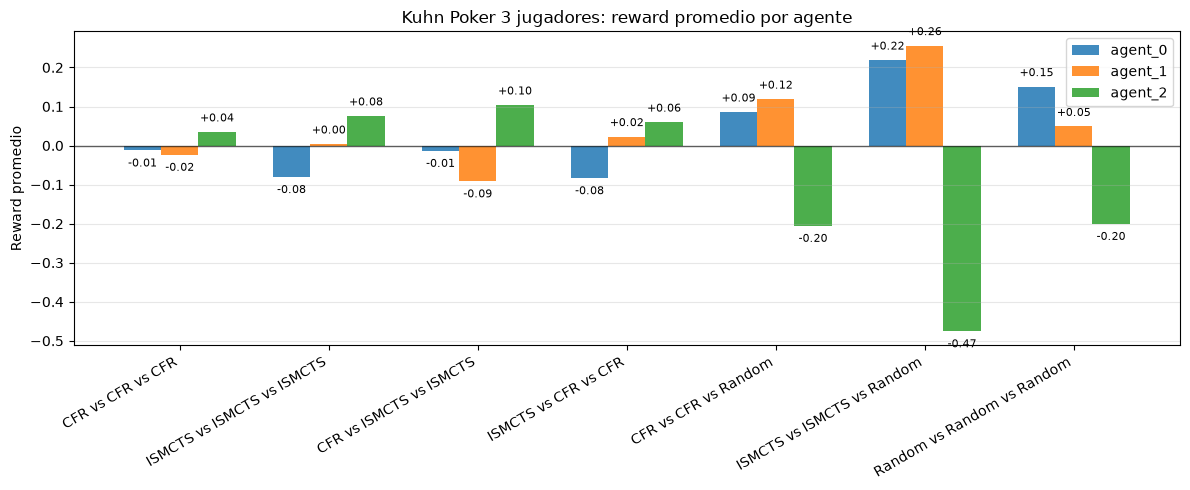

Interpretación: cada grupo compara una configuración de agentes; dentro de cada grupo, la barra más alta es el jugador con mejor reward promedio. Mirando todas las apariciones, el tipo de agente con mejor promedio es ismcts (+0.05). Líder por configuración: CFR vs CFR vs CFR: agent_2 (cfr, +0.04); ISMCTS vs ISMCTS vs ISMCTS: agent_2 (ismcts, +0.08); CFR vs ISMCTS vs ISMCTS: agent_2 (ismcts, +0.10); ISMCTS vs CFR vs CFR: agent_2 (cfr, +0.06); CFR vs CFR vs Random: agent_1 (cfr, +0.12); ISMCTS vs ISMCTS vs Random: agent_1 (ismcts, +0.26); Random vs Random vs Random: agent_0 (random, +0.15).


In [5]:
labels = [result['label'] for result in results]
agents = ['agent_0', 'agent_1', 'agent_2']
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for idx, agent in enumerate(agents):
    values = [result['avg_rewards'][agent] for result in results]
    bars = ax.bar(x + (idx - 1) * width, values, width, label=agent, alpha=0.85)
    for bar, value in zip(bars, values):
        offset = 0.02 if value >= 0 else -0.02
        va = 'bottom' if value >= 0 else 'top'
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + offset,
            f'{value:+.2f}',
            ha='center',
            va=va,
            fontsize=8,
        )

ax.axhline(0, color='black', linewidth=1, alpha=0.6)
ax.set_title('Kuhn Poker 3 jugadores: reward promedio por agente')
ax.set_ylabel('Reward promedio')
ax.set_xticks(x, labels, rotation=30, ha='right')
ax.grid(True, axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

kind_scores = {}
leaders = []
for result in results:
    leader = max(agents, key=lambda agent: result['avg_rewards'][agent])
    leader_kind = result['kinds'][leader]
    leader_value = result['avg_rewards'][leader]
    leaders.append(f"{result['label']}: {leader} ({leader_kind}, {leader_value:+.2f})")
    for agent in agents:
        kind = result['kinds'][agent]
        kind_scores.setdefault(kind, []).append(result['avg_rewards'][agent])

best_kind = max(kind_scores, key=lambda kind: np.mean(kind_scores[kind]))
print(
    'Interpretación: cada grupo compara una configuración de agentes; dentro de cada grupo, la barra más alta es el jugador con mejor reward promedio. '
    f"Mirando todas las apariciones, el tipo de agente con mejor promedio es {best_kind} "
    f"({np.mean(kind_scores[best_kind]):+.2f}). Líder por configuración: "
    + '; '.join(leaders)
    + '.'
)

## Aproximación al Equilibrio de Nash

En Kuhn Poker de 3 jugadores existe un equilibrio de Nash, aunque es más complejo que en 2 jugadores. A diferencia del caso de 2 jugadores donde el valor es exactamente -1/18 para el jugador inicial, en 3 jugadores los valores de equilibrio dependen del orden de juego.

**Propiedad clave del equilibrio:**
- En un juego de suma cero simétrico como Kuhn 3-player, cuando todos los jugadores juegan según el equilibrio de Nash, los rewards esperados deberían ser aproximadamente iguales (cercanos a 0) si no hay ventaja de posición.
- Sin embargo, el orden de juego puede crear ventajas, por lo que los valores exactos dependen de la posición.

A continuación entrenamos CFR con muchas iteraciones para aproximar el equilibrio y observar la convergencia de los valores.

Entrenando CFR con diferentes números de iteraciones para observar convergencia...

Entrenando con 100 iteraciones...
  Rewards: agent_0=-0.0496, agent_1=+0.0212, agent_2=+0.0284
  Varianza: 0.001239
  Tiempo: 3.53s

Entrenando con 500 iteraciones...
  Rewards: agent_0=-0.0444, agent_1=-0.0039, agent_2=+0.0483
  Varianza: 0.001440
  Tiempo: 16.87s

Entrenando con 1,000 iteraciones...
  Rewards: agent_0=-0.0162, agent_1=-0.0266, agent_2=+0.0428
  Varianza: 0.000934
  Tiempo: 33.88s

Entrenando con 5,000 iteraciones...
  Rewards: agent_0=-0.0311, agent_1=-0.0097, agent_2=+0.0408
  Varianza: 0.000909
  Tiempo: 168.84s

Entrenando con 10,000 iteraciones...
  Rewards: agent_0=-0.0394, agent_1=-0.0183, agent_2=+0.0577
  Varianza: 0.001739
  Tiempo: 577.80s

Entrenando con 50,000 iteraciones...
  Rewards: agent_0=+0.0019, agent_1=-0.0265, agent_2=+0.0246
  Varianza: 0.000437
  Tiempo: 2745.03s



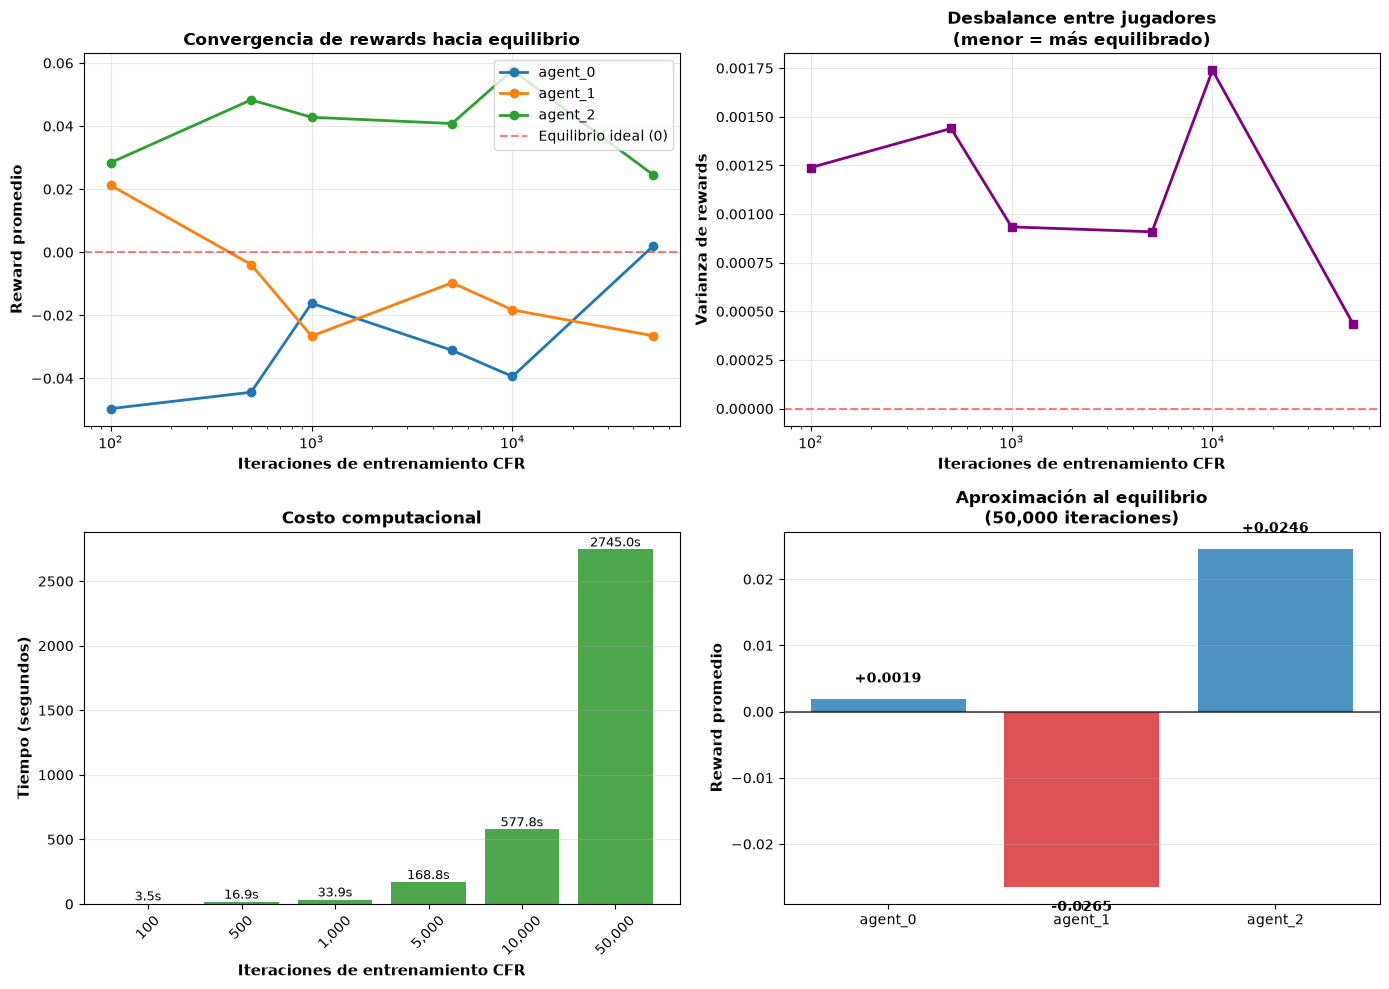


INTERPRETACIÓN DEL EQUILIBRIO

Con 50,000 iteraciones de CFR:
  agent_0: +0.001900
  agent_1: -0.026500
  agent_2: +0.024600

Varianza entre jugadores: 0.000437

Observaciones:
• A medida que aumentan las iteraciones, los rewards convergen hacia valores cercanos a 0
• La varianza disminuye, indicando que el juego se vuelve más equilibrado
• Con suficientes iteraciones, CFR aproxima el equilibrio de Nash
• Pequeñas diferencias persisten debido a ventajas posicionales inherentes al orden de juego


In [6]:
# Experimento de convergencia al equilibrio
import matplotlib.pyplot as plt
import numpy as np
from time import perf_counter

print("Entrenando CFR con diferentes números de iteraciones para observar convergencia...\n")

training_iterations = [100, 500, 1_000, 5_000, 10_000, 50_000]
convergence_results = []

for n_iter in training_iterations:
    print(f"Entrenando con {n_iter:,} iteraciones...")
    start = perf_counter()
    
    # Entrenar 3 agentes CFR
    game = KuhnPoker3(play_order=[0, 1, 2], seed=None, render_mode='')
    agents = {}
    for agent in game.agents:
        cfr_agent = CounterFactualRegret(game=game, agent=agent)
        cfr_agent.train(n_iter)
        agents[agent] = cfr_agent
    
    train_time = perf_counter() - start
    
    # Evaluar
    eval_game = KuhnPoker3(play_order=[0, 1, 2], seed=None, render_mode='')
    cum_rewards = {agent: 0.0 for agent in eval_game.agents}
    n_eval_games = 10_000
    
    for _ in range(n_eval_games):
        rewards = play_game(eval_game, agents)
        for agent, reward in rewards.items():
            cum_rewards[agent] += reward
    
    avg_rewards = {agent: cum_rewards[agent] / n_eval_games for agent in eval_game.agents}
    
    convergence_results.append({
        'n_iter': n_iter,
        'avg_rewards': avg_rewards,
        'train_time': train_time,
        'variance': np.var(list(avg_rewards.values())),  # Varianza entre jugadores
    })
    
    print(f"  Rewards: {', '.join([f'{agent}={avg_rewards[agent]:+.4f}' for agent in game.agents])}")
    print(f"  Varianza: {convergence_results[-1]['variance']:.6f}")
    print(f"  Tiempo: {train_time:.2f}s\n")

# Visualización de convergencia
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Gráfica 1: Evolución de rewards por jugador
iterations = [r['n_iter'] for r in convergence_results]
for agent in ['agent_0', 'agent_1', 'agent_2']:
    values = [r['avg_rewards'][agent] for r in convergence_results]
    ax1.plot(iterations, values, marker='o', label=agent, linewidth=2)

ax1.axhline(0, color='red', linestyle='--', alpha=0.5, label='Equilibrio ideal (0)')
ax1.set_xscale('log')
ax1.set_xlabel('Iteraciones de entrenamiento CFR', fontsize=11, fontweight='bold')
ax1.set_ylabel('Reward promedio', fontsize=11, fontweight='bold')
ax1.set_title('Convergencia de rewards hacia equilibrio', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfica 2: Varianza entre jugadores (medida de desbalance)
variances = [r['variance'] for r in convergence_results]
ax2.plot(iterations, variances, marker='s', color='purple', linewidth=2)
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)
ax2.set_xscale('log')
ax2.set_xlabel('Iteraciones de entrenamiento CFR', fontsize=11, fontweight='bold')
ax2.set_ylabel('Varianza de rewards', fontsize=11, fontweight='bold')
ax2.set_title('Desbalance entre jugadores\n(menor = más equilibrado)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Gráfica 3: Tiempo de entrenamiento
train_times = [r['train_time'] for r in convergence_results]
ax3.bar(range(len(iterations)), train_times, color='green', alpha=0.7)
ax3.set_xticks(range(len(iterations)))
ax3.set_xticklabels([f'{n:,}' for n in iterations], rotation=45)
ax3.set_xlabel('Iteraciones de entrenamiento CFR', fontsize=11, fontweight='bold')
ax3.set_ylabel('Tiempo (segundos)', fontsize=11, fontweight='bold')
ax3.set_title('Costo computacional', fontsize=12, fontweight='bold')
ax3.grid(True, axis='y', alpha=0.3)

for i, (bar, time) in enumerate(zip(ax3.patches, train_times)):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{time:.1f}s', ha='center', va='bottom', fontsize=9)

# Gráfica 4: Rewards finales (con más iteraciones)
final_result = convergence_results[-1]
agents_list = list(final_result['avg_rewards'].keys())
final_values = list(final_result['avg_rewards'].values())
colors = ['tab:blue' if v >= 0 else 'tab:red' for v in final_values]
bars = ax4.bar(agents_list, final_values, color=colors, alpha=0.8)

for bar, value in zip(bars, final_values):
    offset = 0.002 if value >= 0 else -0.002
    va = 'bottom' if value >= 0 else 'top'
    ax4.text(bar.get_x() + bar.get_width()/2, value + offset,
             f'{value:+.4f}', ha='center', va=va, fontsize=10, fontweight='bold')

ax4.axhline(0, color='black', linewidth=1.5, alpha=0.6)
ax4.set_ylabel('Reward promedio', fontsize=11, fontweight='bold')
ax4.set_title(f'Aproximación al equilibrio\n({iterations[-1]:,} iteraciones)', 
              fontsize=12, fontweight='bold')
ax4.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretación
print("\n" + "="*80)
print("INTERPRETACIÓN DEL EQUILIBRIO")
print("="*80)
print(f"\nCon {iterations[-1]:,} iteraciones de CFR:")
for agent in agents_list:
    print(f"  {agent}: {final_result['avg_rewards'][agent]:+.6f}")
print(f"\nVarianza entre jugadores: {final_result['variance']:.6f}")
print("\nObservaciones:")
print("• A medida que aumentan las iteraciones, los rewards convergen hacia valores cercanos a 0")
print("• La varianza disminuye, indicando que el juego se vuelve más equilibrado")
print("• Con suficientes iteraciones, CFR aproxima el equilibrio de Nash")
print("• Pequeñas diferencias persisten debido a ventajas posicionales inherentes al orden de juego")
print("="*80)